<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Resumen Clase 1, Fundamentos del Forecasting Moderno**

---

Importamos las librerias necesarias

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Ignoramos los warnings y definimos semilla para garantizar que se obtendran los mismos números aleatorios cada vez que ejecutemos el código.

In [3]:
warnings.filterwarnings("ignore")
rng = np.random.default_rng(7)

Descargamos el dataset stocks de `vega-datasets`: precios mensuales de cierre de 5 acciones tecnológicas: Apple, Amazon, Google, IBM y Microsoft, entre 2000 y 2010 (560 filas, formato long: símbolo, fecha, precio). Es un dataset público y conocido. Google (GOOG) arranca recién en 2004 por su salida a bolsa, por eso esa serie es más corta. Como ancla univariada el notebook usaremos AAPL, y como panel usa las cinco juntas.

In [4]:
URL = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/stocks.csv"
raw = pd.read_csv(URL)
raw["date"] = pd.to_datetime(raw["date"], format="%b %d %Y")
raw = raw.sort_values(["symbol", "date"]).reset_index(drop=True)

Serie ancla univariada: AAPL (historia completa de Apple, 2000–2010)

In [5]:
TICKER = "AAPL"

Filtramos únicamente Apple, usamos la fecha como índice

In [6]:
serie = raw[raw.symbol == TICKER].set_index("date")["price"].asfreq("MS")

In [7]:
print(serie)

date
2000-01-01     25.94
2000-02-01     28.66
2000-03-01     33.95
2000-04-01     31.01
2000-05-01     21.00
               ...  
2009-11-01    199.91
2009-12-01    210.73
2010-01-01    192.06
2010-02-01    204.62
2010-03-01    223.02
Freq: MS, Name: price, Length: 123, dtype: float64


Convertimos a numpy

In [8]:
y = serie.values.astype(float)

Mostramos información

In [9]:
print(f"Dataset real: {raw.symbol.nunique()} acciones, {raw.date.min().date()}–{raw.date.max().date()}")
print(f"Serie ancla: {TICKER}, {len(serie)} meses")

Dataset real: 5 acciones, 2000-01-01–2010-03-01
Serie ancla: AAPL, 123 meses


Graficamos la evolución del precio en el tiempo

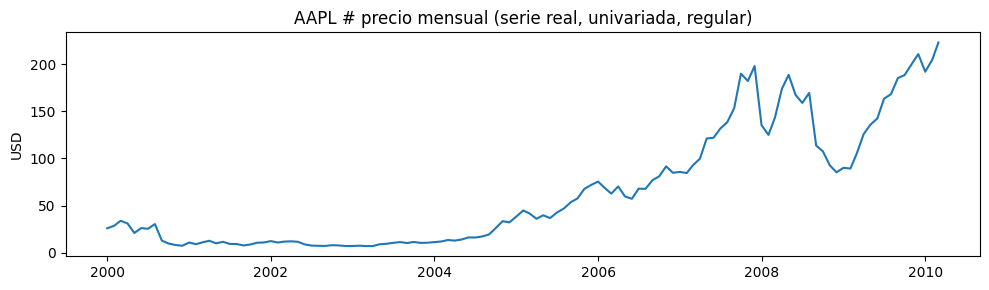

In [10]:
plt.figure(figsize=(10, 3))
plt.plot(serie.index, serie.values)
plt.title(f"{TICKER} # precio mensual (serie real, univariada, regular)")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

### **Ejercicio 1, Una serie no es un dataset común**

No i.i.d.: el orden es información. Lo vemos por la autocorrelación de lag-1 y por la no estacionriedad (media/desvio que cambian).

**Comparamos y(t) vs y(t+1)**

Si la correlación es alta significa que si se conoce el valor actual, tenemos mucha información sobre el siguiente.

In [11]:
lag1 = np.corrcoef(y[:-1], y[1:])[0, 1]
print(f"Autocorrelación lag-1 ({TICKER} ordenada): {lag1:.3f}  -> casi random walk, mucha dependencia")

Autocorrelación lag-1 (AAPL ordenada): 0.983  -> casi random walk, mucha dependencia


Tenemos la no estacionariedad (no "identically distributed"), media/desvío que se mueven

In [12]:
print(f"Media 2000–2003: {y[:36].mean():7.2f} σ: {y[:36].std():6.2f}") # primeros 36 meses
print(f"Media 2007–2010: {y[-36:].mean():7.2f} σ: {y[-36:].std():6.2f}, la distribución cambia") # últimos 36 meses

Media 2000–2003:   13.78 σ:   7.88
Media 2007–2010:  150.64 σ:  38.54, la distribución cambia


El orden es información: al barajar, la autocorrelación se destruye

In [13]:
y_shuf = y.copy(); rng.shuffle(y_shuf)

Calculamos otra vez la autocorrelación

In [14]:
lag1_shuf = np.corrcoef(y_shuf[:-1], y_shuf[1:])[0, 1]
print(f"Autocorrelación lag-1 (barajada): {lag1_shuf:.3f}, el orden tenía la señal")

Autocorrelación lag-1 (barajada): -0.017, el orden tenía la señal


Graficamos las series

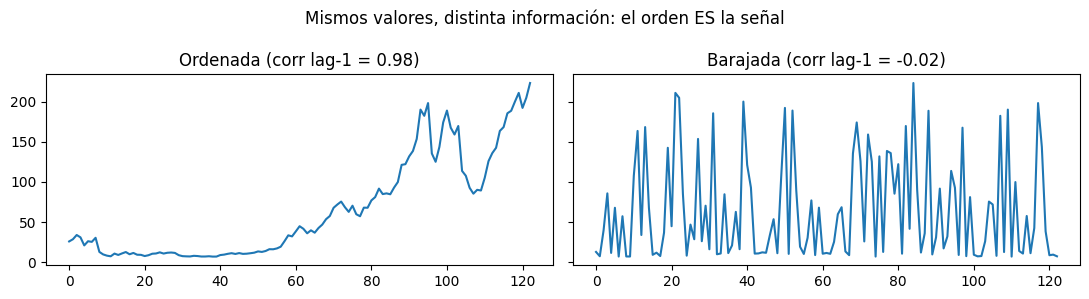

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
ax[0].plot(y);      ax[0].set_title(f"Ordenada (corr lag-1 = {lag1:.2f})")
ax[1].plot(y_shuf); ax[1].set_title(f"Barajada (corr lag-1 = {lag1_shuf:.2f})")
fig.suptitle("Mismos valores, distinta información: el orden ES la señal")
plt.tight_layout()
plt.show()

Así nos percatamos de nunca barajar ni hacer k-fold aleatorio (rompe la señal y mete futuro en el train).

---

### **Ejercicio 2, Representación Temporal**

* Vemos la representación temporal: univariada, regular/irregular y panel real

Verificamos que la serie es regular. MS significa Month Start. Hay una observación cada mes.

In [16]:
print("Frecuencia del índice:", serie.index.freqstr)

Frecuencia del índice: MS


**Creamos una serie irregular**

Seleccionamos aleatoriamente 80 meses y eliminamos el resto.

In [17]:
keep = np.sort(rng.choice(len(serie), size=80, replace=False))
serie_irr = serie.iloc[keep]
print(serie_irr)

date
2000-01-01     25.94
2000-02-01     28.66
2000-03-01     33.95
2000-04-01     31.01
2000-05-01     21.00
               ...  
2009-09-01    185.35
2009-10-01    188.50
2009-11-01    199.91
2010-01-01    192.06
2010-03-01    223.02
Name: price, Length: 80, dtype: float64


Medimos los intervalos entre observaciones, calcula fecha actual - fecha anterior



In [18]:
deltas = serie_irr.index.to_series().diff().dropna().dt.days
print(deltas)
print(f"Serie irregular simulada: Δt entre {deltas.min()} y {deltas.max()} días")

date
2000-02-01    31
2000-03-01    29
2000-04-01    31
2000-05-01    30
2000-07-01    61
              ..
2009-09-01    62
2009-10-01    30
2009-11-01    31
2010-01-01    61
2010-03-01    59
Name: date, Length: 79, dtype: int64
Serie irregular simulada: Δt entre 28 y 122 días


Ya no existe un intervalo constante. La serie es irregular.

**Regularizamos la serie**

Primero reconstruimos todos los meses. Después interpolamos, rellenando los huecos.

In [19]:
serie_reg = serie_irr.resample("MS").mean().interpolate()
print(serie_reg)
print(f"Tras regularizar (resample + interpolar): {len(serie_reg)} puntos a Δt fijo")

date
2000-01-01     25.940
2000-02-01     28.660
2000-03-01     33.950
2000-04-01     31.010
2000-05-01     21.000
               ...   
2009-11-01    199.910
2009-12-01    195.985
2010-01-01    192.060
2010-02-01    207.540
2010-03-01    223.020
Freq: MS, Name: price, Length: 123, dtype: float64
Tras regularizar (resample + interpolar): 123 puntos a Δt fijo


Creamos panel data. Cambiamos los nombres.

In [20]:
panel = raw.rename(columns={"symbol": "serie_id", "date": "ds", "price": "y"})

In [21]:
print("\nPanel real (long), cabecera:")
print(panel.head(3).to_string(index=False))


Panel real (long), cabecera:
serie_id         ds     y
    AAPL 2000-01-01 25.94
    AAPL 2000-02-01 28.66
    AAPL 2000-03-01 33.95


Vemos cuántas observaciones tiene cada serie

In [22]:
print("Series y largos:", panel.groupby("serie_id").size().to_dict())  # GOOG es más corta (IPO 2004)

Series y largos: {'AAPL': 123, 'AMZN': 123, 'GOOG': 68, 'IBM': 123, 'MSFT': 123}


Graficamos todas las series, las 5 acciones en paralelo (formato long).

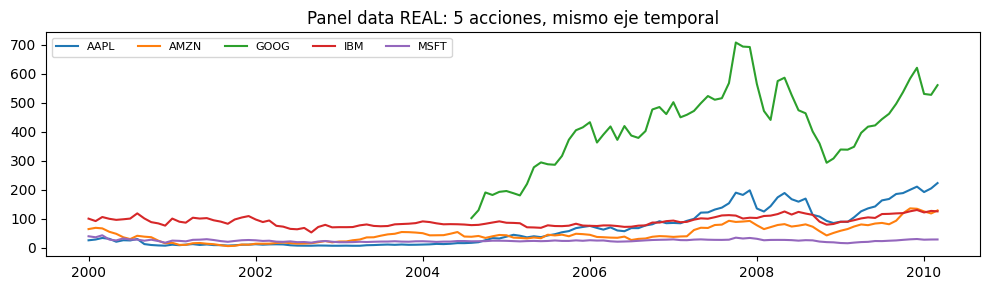

In [23]:
plt.figure(figsize=(10, 3))
for sid, g in panel.groupby("serie_id"):
    plt.plot(g.ds, g.y, label=sid)
plt.legend(ncol=5, fontsize=8); plt.title("Panel data REAL: 5 acciones, mismo eje temporal")
plt.tight_layout()
plt.show()

---

### **Ejercicio 3, Conversión a Problema Supervisado**

Definimos una función que transforma una serie temporal en un dataset supervisado.

**Sliding Window**

Arma (X, y) sin romper el orden.
* X = ventana de n_lags
* y = horizonte de horizon pasos

In [24]:
def make_supervised(values, n_lags, horizon=1):
    # Convertimos los datos a un array NumPy
    values = np.asarray(values, dtype=float)
    X, Y = [], []

    # Realiza muestras supervisadas
    for i in range(len(values) - n_lags - horizon + 1):
        X.append(values[i:i + n_lags])
        Y.append(values[i + n_lags:i + n_lags + horizon])
    return np.array(X), np.array(Y)

Cada fila de X contiene 12 meses de historia y el target es Enero del siguiente año

In [25]:
N_LAGS = 12
Xd0, yd0 = make_supervised(y, N_LAGS, horizon=1)

In [26]:
print(f"Serie de {Xd0.shape[0]} muestras supervisadas; X shape = {Xd0.shape}")
print(f"Primera muestra: X = {Xd0[0].round(1)}, y = {yd0[0].round(1)}")

Serie de 111 muestras supervisadas; X shape = (111, 12)
Primera muestra: X = [25.9 28.7 34.  31.  21.  26.2 25.4 30.5 12.9  9.8  8.2  7.4], y = [10.8]


**Rolling Window**

No estamos creando ejemplos para entrenar. Estamos creando una nueva característica.

In [27]:
rolling_mean = serie.rolling(N_LAGS).mean()
print(rolling_mean.dropna().head(3).round(2).to_string())

date
2000-12-01    21.75
2001-01-01    20.49
2001-02-01    18.86
Freq: MS


* Sliding Window transforma serie temporal en dataset supervisado. Sirve para entrenar modelos.

* Rolling Window transforma serie temporal en nueva serie temporal. Sirve para feature engineering.

### **Ejercicio 4, Estrategias de forecasting: recursive y direct**

Las dos estrategias usan el mismo modelo base (StandardScaler + MLP con los mismos hiperparametros y semilla). Asi, cualquier diferencia de error es atribuible a la estrategia, no al modelo.
* Recursive : 1 red a 1 paso, se realimenta con sus propias predicciones
* Direct : H redes independientes, una por horizonte (no comparten nada)

Realizamos la separación train/test. Si tenemos 120 meses, entonces los primeros 108 meses son para el train mientras que los últimos 12 meses para el test.

In [28]:
H = 12
train, test = y[:-H], y[-H:]

Modelo base unico para las dos estrategias

In [29]:
def base_model():
    return make_pipeline(
        StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=4000, random_state=0),
    )

### **Ejercicio 4.1**

**Estrategia Recursive**

* Un modelo a 1 paso, realimenta sus predicciones

Convertimos el dataset a un modelo supervisado

In [30]:
Xr, yr = make_supervised(train, N_LAGS, horizon=1)

La regresión aprende el siguiente mes a partir de los 12 meses pasados. Sólo sabe predecir 1 paso adelante.

In [31]:
rec = base_model().fit(Xr, yr.ravel())

Definimos función para realizar el forecast de manera recursiva. El modelo realiza una predicción, luego usa esta misma dentro de la ventana para realizar la siguiente predicción y asi sucesivamente.

In [32]:
def forecast_recursive(model, last_window, steps):
    w, out = list(last_window), []
    for _ in range(steps):
        p = model.predict(np.array(w[-N_LAGS:]).reshape(1, -1))[0]
        out.append(p); w.append(p)
    return np.array(out)

In [33]:
pred_rec = forecast_recursive(rec, train[-N_LAGS:], H)

El problema es que cada error se reutiliza. Si el primer forecast es malo, entonces las siguientes predicciones también se desvían. Por eso se llama error accumulation

### **Ejercicio 4.2**

**Estrategia Direct**

* Un modelo por horizonte (sin realimentación)

Convertimos el dataset a un modelo supervisado. Un modelo distinto para cada horizonte.

In [34]:
Xd, Yd = make_supervised(train, N_LAGS, horizon=H)
direct = [base_model().fit(Xd, Yd[:, h]) for h in range(H)]

Extrae la última ventana observada del train y lo transforma con reshape porque scikit-learn espera una matriz con forma (n_muestras, n_features).

In [35]:
last_win = train[-N_LAGS:].reshape(1, -1)

Cada modelo genera su propia predicción. El resultado final es un vector. A diferencia del forecasting recursive, aquí nunca se reutilizan predicciones como entrada del siguiente paso.

In [36]:
pred_dir = np.array([m.predict(last_win)[0] for m in direct])

Visualizamos los resultados

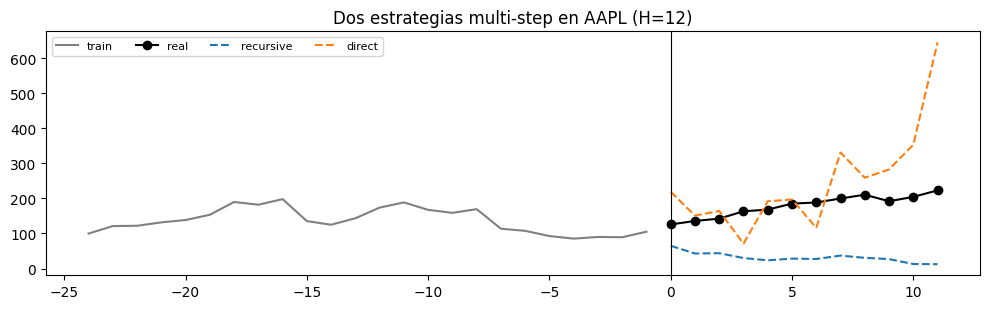

In [37]:
plt.figure(figsize=(10, 3.2))
plt.plot(range(-24, 0), train[-24:], color="gray", label="train")
plt.plot(range(H), test, "k-o", label="real")
plt.plot(range(H), pred_rec, "--", label="recursive")
plt.plot(range(H), pred_dir, "--", label="direct")
plt.axvline(0, color="k", lw=0.8); plt.legend(ncol=5, fontsize=8)
plt.title(f"Dos estrategias multi-step en {TICKER} (H=12)")
plt.tight_layout()
plt.show()